In [1]:
from pathlib import Path

import xarray as xr
import xcdat as xc
from hadley_cell_metrics import hadley_cell_metrics

## Raw ERA-5 Data

In [ ]:
model_name = 'ERA5-raw-data'
vwnd_data_path = "/global/cfs/projectdirs/m4581/obs4MIPs/obs4MIPs_input/ECMWF/ERA5/RDA/va-plev37"
psl_data_path = "/global/cfs/projectdirs/m4581/obs4MIPs/obs4MIPs_input/ECMWF/ERA5/RDA/psl"
data_output_path = "/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804"

In [3]:
vwnd_files = sorted(Path(vwnd_data_path).glob("*.nc"))
psl_files = sorted(Path(psl_data_path).glob("*.nc"))

if not vwnd_files:
        raise FileNotFoundError(f"No .nc files found in {vwnd_data_path}")
if not psl_files:
    raise FileNotFoundError(f"No .nc files found in {psl_data_path}")

vwnd_datasets = xr.open_mfdataset(vwnd_files, combine="by_coords")
ps_datasets = xr.open_mfdataset(psl_files, combine="by_coords")

In [4]:
target_grid = xc.regridder.grid.create_uniform_grid(-90, 90, 2, -180, 180, 2)
vwnd_regridded = vwnd_datasets.regridder.horizontal('V', target_grid, tool='xesmf', method='bilinear')
ps_regridded = ps_datasets.regridder.horizontal('MSL', target_grid, tool='xesmf', method='bilinear')

In [ ]:
hadley_cell_metrics(
    vwnd_ds = vwnd_regridded,
    ps_ds = ps_regridded,
    vwnd_var = 'V',
    ps_var = 'MSL',
    output_dir = data_output_path,
    model_name = model_name,
    lev_dim = 'level'
)

Saved: /global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-raw-data_monthly_psi.nc
Saved: /global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-raw-data_annual_edges.nc
Saved: /global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-raw-data_seasonal_psi.png
Saved: /global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-raw-data_clim_psi500.nc


{'monthly_psi': '/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-raw-data_monthly_psi.nc',
 'annual_edges': '/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-raw-data_annual_edges.nc',
 'clim_psi500': '/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-raw-data_clim_psi500.nc',
 'clim_plot': '/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-raw-data_seasonal_psi.png'}

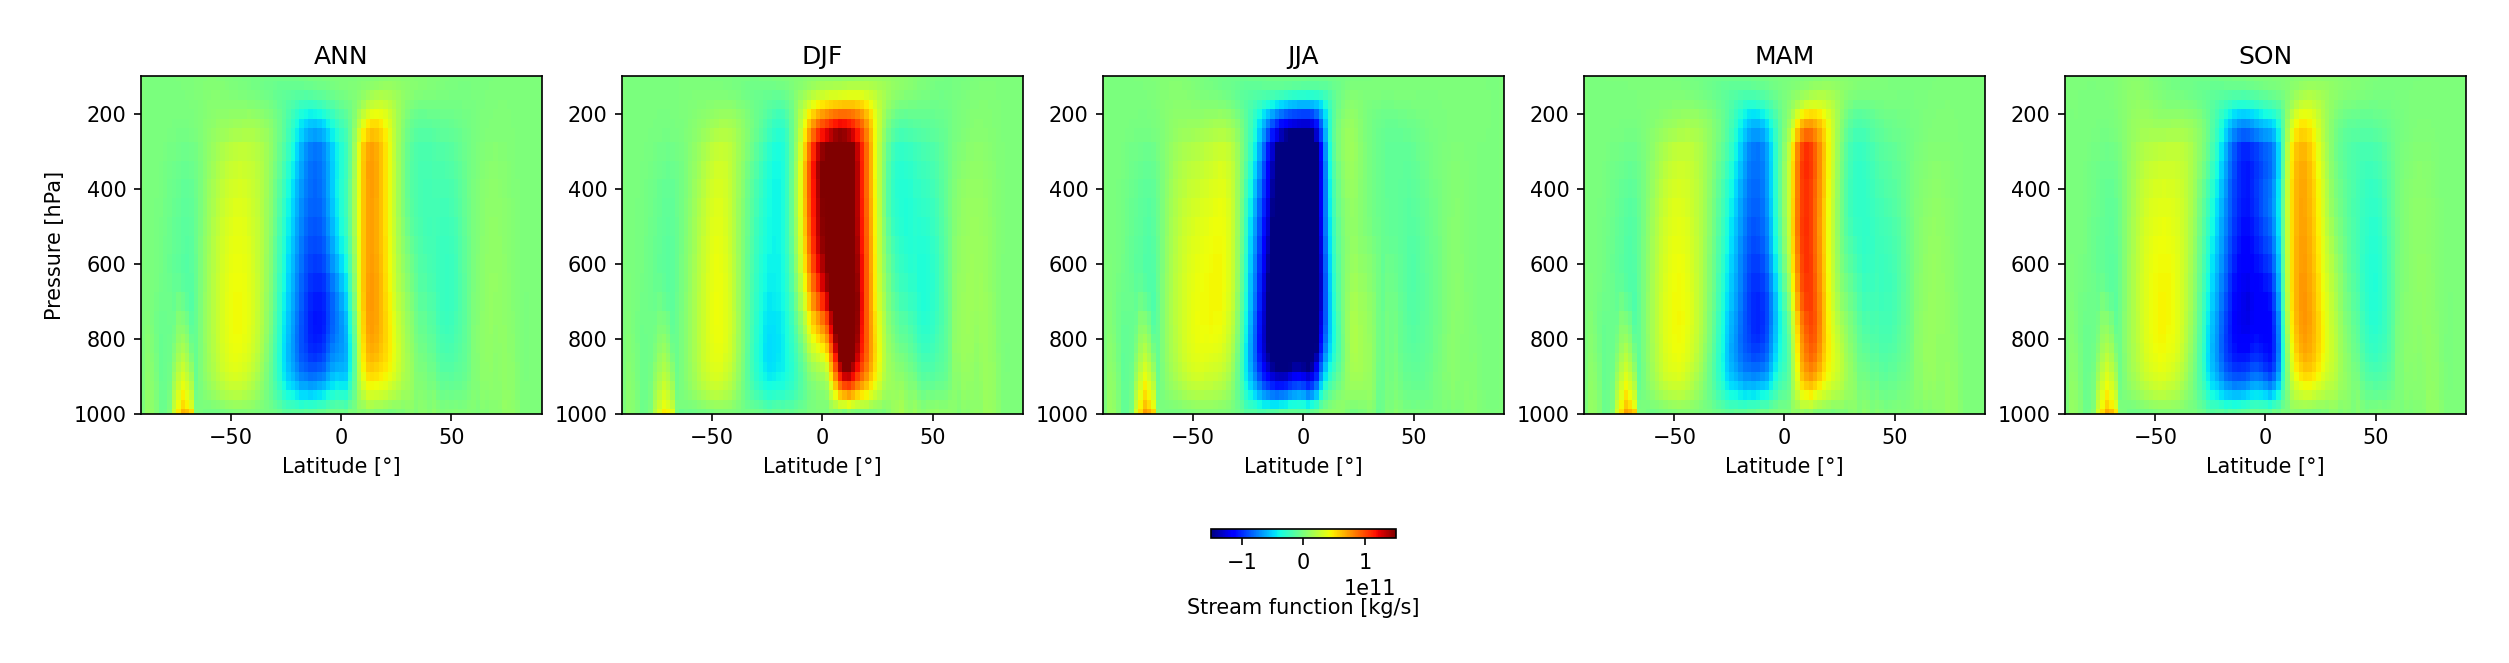

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Read the PNG image
img = mpimg.imread(f'{data_output_path}/{model_name}_seasonal_psi.png')

# Display high quality image without layout padding
height, width, _ = img.shape
fig = plt.figure(figsize=(width/300, height/300), dpi=300)

ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)

ax.imshow(img)
plt.show()

In [ ]:
edges = xr.open_dataset(f'{data_output_path}/{model_name}_annual_edges.nc')

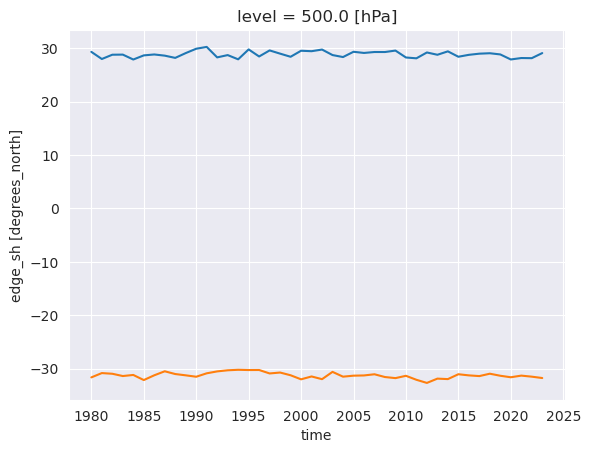

In [15]:
import seaborn as sns

sns.set_style(style="darkgrid")
edges.edge_nh.plot(x='time')
edges.edge_sh.plot(x='time')

## Obs4MIPs

In [21]:
model_name = 'ERA5-Obs4MIPs-data'
vwnd_data_path = "/global/cfs/projectdirs/m4581/obs4MIPs/obs4MIPs/ECMWF/ERA-5/mon/va/gn/latest"
psl_data_path = "/global/cfs/projectdirs/m4581/obs4MIPs/obs4MIPs/ECMWF/ERA-5/mon/psl/gn/latest"
data_output_path = "/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804"

In [22]:
vwnd_files = sorted(Path(vwnd_data_path).glob("*.nc"))
psl_files = sorted(Path(psl_data_path).glob("*.nc"))

if not vwnd_files:
        raise FileNotFoundError(f"No .nc files found in {vwnd_data_path}")
if not psl_files:
    raise FileNotFoundError(f"No .nc files found in {psl_data_path}")

vwnd_datasets = xr.open_mfdataset(vwnd_files, combine="by_coords")
ps_datasets = xr.open_mfdataset(psl_files, combine="by_coords")

/tmp/ipykernel_325468/2131145780.py:9: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  vwnd_datasets = xr.open_mfdataset(vwnd_files, combine="by_coords")
/tmp/ipykernel_325468/2131145780.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ps_datasets = xr.open_mfdataset(psl_files, combine="by_coords")


In [23]:
target_grid = xc.regridder.grid.create_uniform_grid(-90, 90, 2, -180, 180, 2)
vwnd_regridded = vwnd_datasets.regridder.horizontal('va', target_grid, tool='xesmf', method='bilinear')
ps_regridded = ps_datasets.regridder.horizontal('psl', target_grid, tool='xesmf', method='bilinear')

In [24]:
hadley_cell_metrics(
    vwnd_ds = vwnd_regridded,
    ps_ds = ps_regridded,
    vwnd_var = 'va',
    ps_var = 'psl',
    output_dir = data_output_path,
    model_name = model_name,
    lev_dim = 'plev'
)

Saved: /global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-Obs4MIPs-data_monthly_psi.nc
Saved: /global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-Obs4MIPs-data_annual_edges.nc
Saved: /global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-Obs4MIPs-data_seasonal_psi.png
Saved: /global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-Obs4MIPs-data_clim_psi500.nc


{'monthly_psi': '/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-Obs4MIPs-data_monthly_psi.nc',
 'annual_edges': '/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-Obs4MIPs-data_annual_edges.nc',
 'clim_psi500': '/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-Obs4MIPs-data_clim_psi500.nc',
 'clim_plot': '/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/test0804/ERA5-Obs4MIPs-data_seasonal_psi.png'}

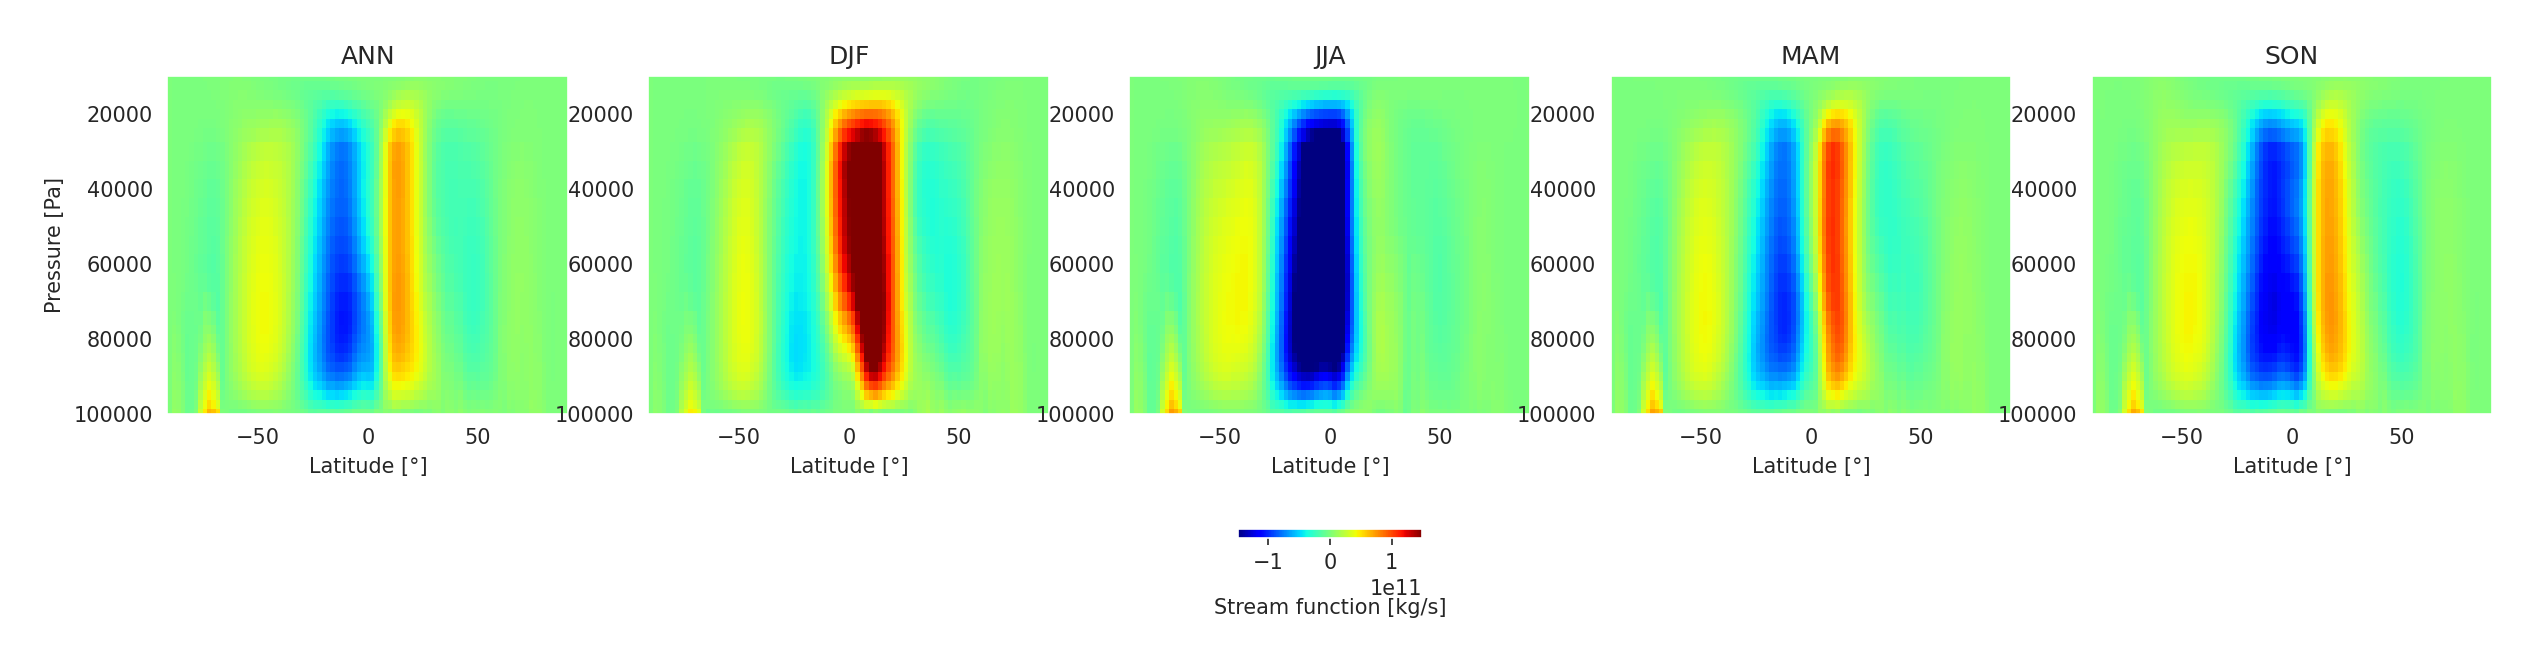

In [25]:
# Read the PNG image
img = mpimg.imread(f'{data_output_path}/{model_name}_seasonal_psi.png')

# Display high quality image without layout padding
height, width, _ = img.shape
fig = plt.figure(figsize=(width/300, height/300), dpi=300)

ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)

ax.imshow(img)
plt.show()

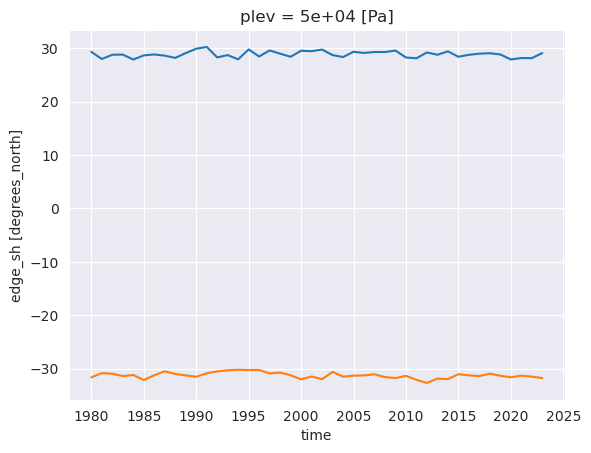

In [26]:
edges = xr.open_dataset(f'{data_output_path}/{model_name}_annual_edges.nc')

sns.set_style(style="darkgrid")
edges.edge_nh.plot(x='time')
edges.edge_sh.plot(x='time')

## E3SM-2-1

In [27]:
model_name = "E3SM-2-1"
vwnd_data_path = "/global/cfs/projectdirs/m3522/datalake/CMIP6/CMIP/E3SM-Project/E3SM-2-1/historical/r1i1p1f1/Amon/va/gr/v20240207"
psl_data_path = "/global/cfs/projectdirs/m3522/datalake/CMIP6/CMIP/E3SM-Project/E3SM-2-1/historical/r1i1p1f1/Amon/psl/gr/v20240206"
data_output_path = "/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/e3sm-2-1"

In [28]:
vwnd_files = sorted(Path(vwnd_data_path).glob("*.nc"))
psl_files = sorted(Path(psl_data_path).glob("*.nc"))

if not vwnd_files:
        raise FileNotFoundError(f"No .nc files found in {vwnd_data_path}")
if not psl_files:
    raise FileNotFoundError(f"No .nc files found in {psl_data_path}")

vwnd_datasets = xr.open_mfdataset(vwnd_files, combine="by_coords")
ps_datasets = xr.open_mfdataset(psl_files, combine="by_coords")

/tmp/ipykernel_325468/2131145780.py:9: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  vwnd_datasets = xr.open_mfdataset(vwnd_files, combine="by_coords")
/tmp/ipykernel_325468/2131145780.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ps_datasets = xr.open_mfdataset(psl_files, combine="by_coords")


In [29]:
target_grid = xc.regridder.grid.create_uniform_grid(-90, 90, 2, -180, 180, 2)
vwnd_regridded = vwnd_datasets.regridder.horizontal('va', target_grid, tool='xesmf', method='bilinear')
ps_regridded = ps_datasets.regridder.horizontal('psl', target_grid, tool='xesmf', method='bilinear')

In [30]:
hadley_cell_metrics(
    vwnd_ds = vwnd_regridded,
    ps_ds = ps_regridded,
    vwnd_var = 'va',
    ps_var = 'psl',
    output_dir = data_output_path,
    model_name = model_name,
    lev_dim = 'plev'
)

Saved: /global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/e3sm-2-1/E3SM-2-1_monthly_psi.nc
Saved: /global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/e3sm-2-1/E3SM-2-1_annual_edges.nc
Saved: /global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/e3sm-2-1/E3SM-2-1_seasonal_psi.png
Saved: /global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/e3sm-2-1/E3SM-2-1_clim_psi500.nc


{'monthly_psi': '/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/e3sm-2-1/E3SM-2-1_monthly_psi.nc',
 'annual_edges': '/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/e3sm-2-1/E3SM-2-1_annual_edges.nc',
 'clim_psi500': '/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/e3sm-2-1/E3SM-2-1_clim_psi500.nc',
 'clim_plot': '/global/cfs/projectdirs/m4581/kchang61/pmp_hadley_cell_implementation/hadley2_ncfiles/e3sm-2-1/E3SM-2-1_seasonal_psi.png'}

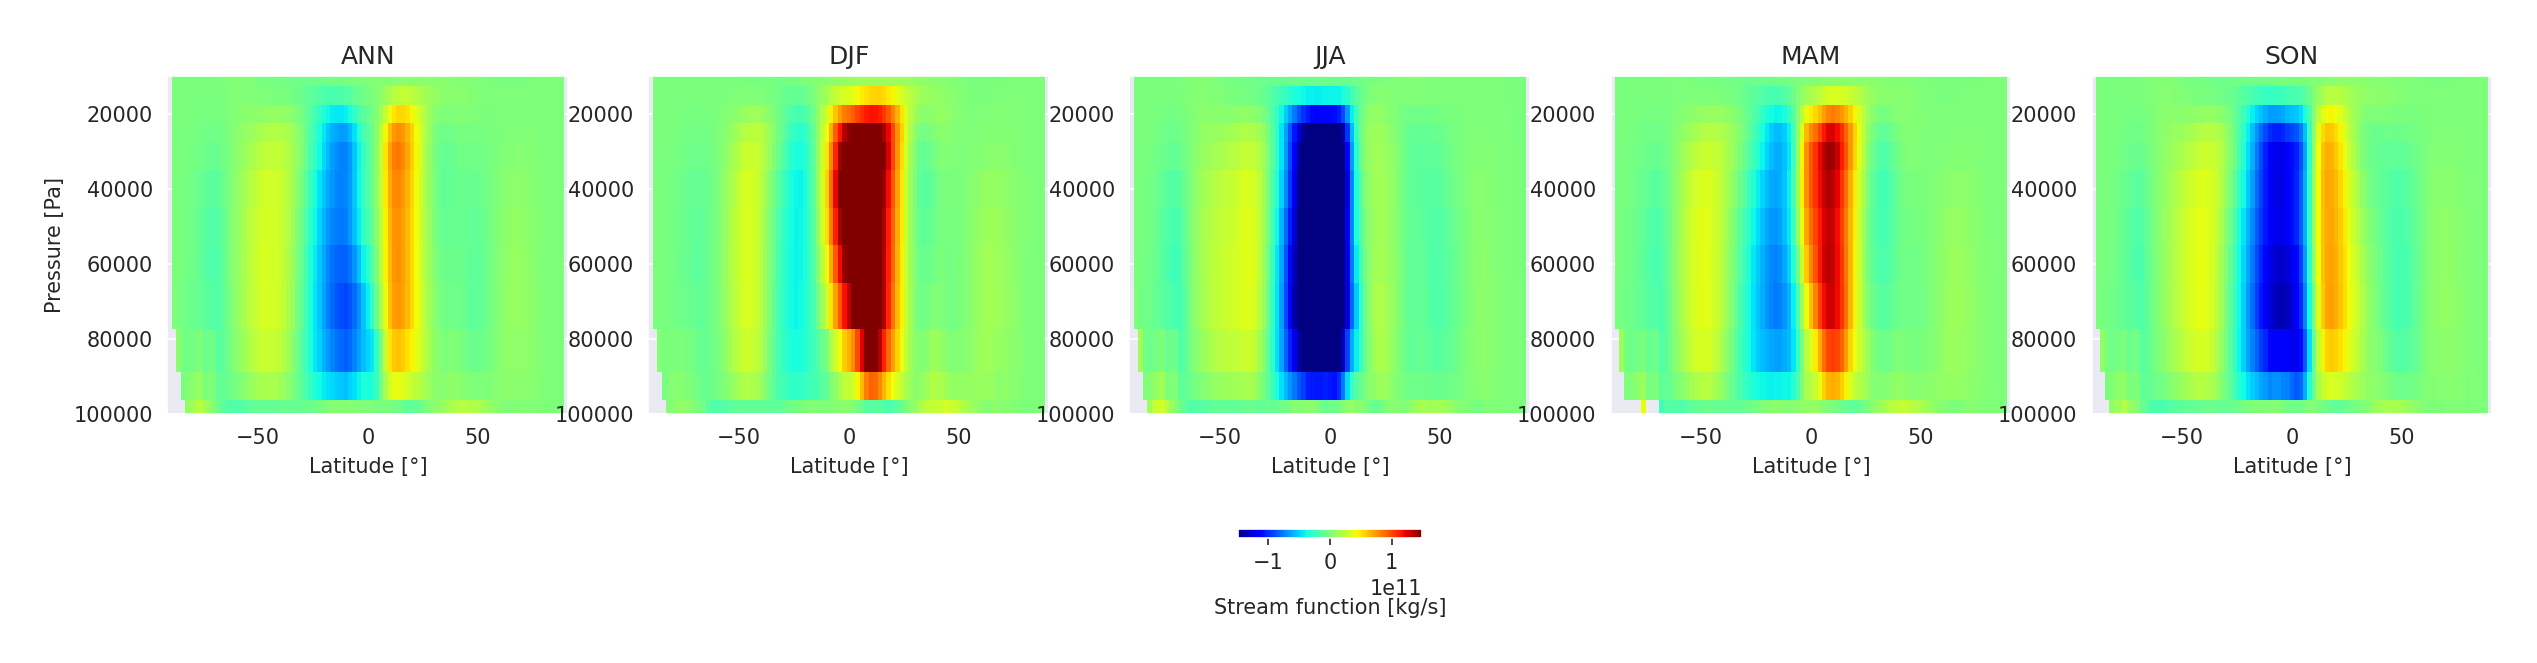

In [31]:
# Read the PNG image
img = mpimg.imread(f'{data_output_path}/{model_name}_seasonal_psi.png')

# Display high quality image without layout padding
height, width, _ = img.shape
fig = plt.figure(figsize=(width/300, height/300), dpi=300)

ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)

ax.imshow(img)
plt.show()

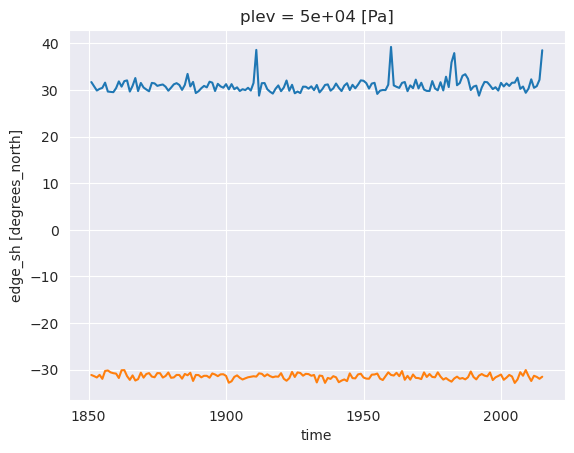

In [32]:
edges = xr.open_dataset(f'{data_output_path}/{model_name}_annual_edges.nc')

sns.set_style(style="darkgrid")
edges.edge_nh.plot(x='time')
edges.edge_sh.plot(x='time')